In [1]:
%pip install pandas numpy matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [7]:
import os
import sys
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from src.preprocess import (
    load_data,
    clean_data,
    encode_data,
    split_features_target
)

In [9]:
df = load_data("../data/agaricus-lepiota.data")

In [10]:
column_names = [
    "poisonous",
    "cap_shape",
    "cap_surface",
    "cap_color",
    "bruises",
    "odor",
    "gill_attachment",
    "gill_spacing",
    "gill_size",
    "gill_color",
    "stalk_shape",
    "stalk_root",
    "stalk_surface_above_ring",
    "stalk_surface_below_ring",
    "stalk_color_above_ring",
    "stalk_color_below_ring",
    "veil_type",
    "veil_color",
    "ring_number",
    "ring_type",
    "spore_print_color",
    "population",
    "habitat"
]

df.columns = column_names

In [11]:
df = clean_data(df)

In [12]:
(df == "?").sum()

poisonous                   0
cap_shape                   0
cap_surface                 0
cap_color                   0
bruises                     0
odor                        0
gill_attachment             0
gill_spacing                0
gill_size                   0
gill_color                  0
stalk_shape                 0
stalk_root                  0
stalk_surface_above_ring    0
stalk_surface_below_ring    0
stalk_color_above_ring      0
stalk_color_below_ring      0
veil_type                   0
veil_color                  0
ring_number                 0
ring_type                   0
spore_print_color           0
population                  0
habitat                     0
dtype: int64

In [13]:
df, encoders = encode_data(df)

In [14]:
X, y = split_features_target(df)

In [15]:
mi = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi_df = pd.DataFrame({
    "Feature": X.columns,
    "Mutual Information": mi
})

mi_df = mi_df.sort_values(
    by="Mutual Information",
    ascending=False
)

mi_df

,Feature,Mutual Information
4,odor,0.629530
19,spore_print_color,0.330191
8,gill_color,0.283913
18,ring_type,0.218053
11,stalk_surface_above_ring,0.203732
12,stalk_surface_below_ring,0.187273
13,stalk_color_above_ring,0.180185
14,stalk_color_below_ring,0.166082
7,gill_size,0.155905
20,population,0.144846


In [32]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns

In [33]:
""" có X và y từ file '03_Feature_Engineering.ipynb'
chia 20% dữ liệu để làm tập Test còn lại 80% là tập Temp,
chia tiếp tập Temp thành Train và Validatoin
25% của 80% là 20% của toàn bộ dữ liệu ban đầu
-> Train là 60%, Val là 20%
"""
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Tinh chỉnh")

# Decision Tree
tham_so_tree = {'max_depth': [3, 5, 7, 10]}
grid_tree = GridSearchCV(DecisionTreeClassifier(random_state=42), tham_so_tree, cv=5)
grid_tree.fit(X_train, y_train)

print(f"Decision Tree tốt nhất: {grid_tree.best_params_}")

# Random Forest
tham_so_rf = {'n_estimators': [10, 50, 100]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), tham_so_rf, cv=5)
grid_rf.fit(X_train, y_train)

print(f"Random Forest tốt nhất: {grid_rf.best_params_}")

print("Đánh giá trên tập Test")
final_tree = grid_tree.best_estimator_
final_rf = grid_rf.best_estimator_

print(f"Điểm thi thật của Decision Tree: {accuracy_score(y_test, final_tree.predict(X_test)):.4f}")
print(f"Điểm thi thật của Random Forest: {accuracy_score(y_test, final_rf.predict(X_test)):.4f}")

Tinh chỉnh
Decision Tree tốt nhất: {'max_depth': 10}
Random Forest tốt nhất: {'n_estimators': 10}
Đánh giá trên tập Test
Điểm thi thật của Decision Tree: 1.0000
Điểm thi thật của Random Forest: 1.0000


In [34]:
# Huấn luyện lại Train
final_tree.fit(X_train, y_train)
final_rf.fit(X_train, y_train)

# Chấm điểm Test
ket_qua_tree = final_tree.predict(X_test)
diem_test_tree = accuracy_score(y_test, ket_qua_tree)

ket_qua_rf = final_rf.predict(X_test)
diem_test_rf = accuracy_score(y_test, ket_qua_rf)

print("Báo cáo đa chỉ số (Random Forest)")
print(classification_report(y_test, ket_qua_rf))

print("Phân tích lỗi (dự đoán sai)")
df_loi = X_test.copy()
df_loi['Thuc_te'] = y_test
df_loi['Du_doan'] = ket_qua_rf

cac_ca_sai = df_loi[df_loi['Thuc_te'] != df_loi['Du_doan']]
so_luong_sai = len(cac_ca_sai)

print(f"Tổng số ca dự đoán sai của Random Forest: {so_luong_sai} / {len(y_test)}")
if so_luong_sai > 0:
    print("Chi tiết các ca sai điển hình:")
    display(cac_ca_sai.head())
else:
    print("Mô hình phân loại hoàn toàn chính xác !")

Báo cáo đa chỉ số (Random Forest)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

Phân tích lỗi (dự đoán sai)
Tổng số ca dự đoán sai của Random Forest: 0 / 1625
Mô hình phân loại hoàn toàn chính xác !


In [37]:
def ve_so_sanh_ma_tran(y_test, pred_tree, pred_rf):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    sns.heatmap(confusion_matrix(y_test, pred_tree), annot=True, fmt='d', cmap='Oranges', ax=axes[0])
    axes[0].set_title('Decision Tree')
    axes[0].set_xlabel('Dự đoán'); axes[0].set_ylabel('Thực tế')
    
    sns.heatmap(confusion_matrix(y_test, pred_rf), annot=True, fmt='d', cmap='Blues', ax=axes[1])
    axes[1].set_title('Random Forest')
    axes[1].set_xlabel('Dự đoán'); axes[1].set_ylabel('Thực tế')
    
    plt.tight_layout()
    plt.show()

def ve_so_sanh_roc(y_test, prob_tree, prob_rf):
    plt.figure(figsize=(8, 6))
    
    fpr_tree, tpr_tree, _ = roc_curve(y_test, prob_tree)
    plt.plot(fpr_tree, tpr_tree, color='darkorange', lw=2, label=f'Decision Tree (AUC = {auc(fpr_tree, tpr_tree):.4f})')
    
    fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf)
    plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.4f})')
    
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('Tỷ lệ FPR'); plt.ylabel('Tỷ lệ TPR')
    plt.title('Đường cong ROC')
    plt.legend(loc="lower right")
    plt.show()

So sánh ma trận nhầm lẫn


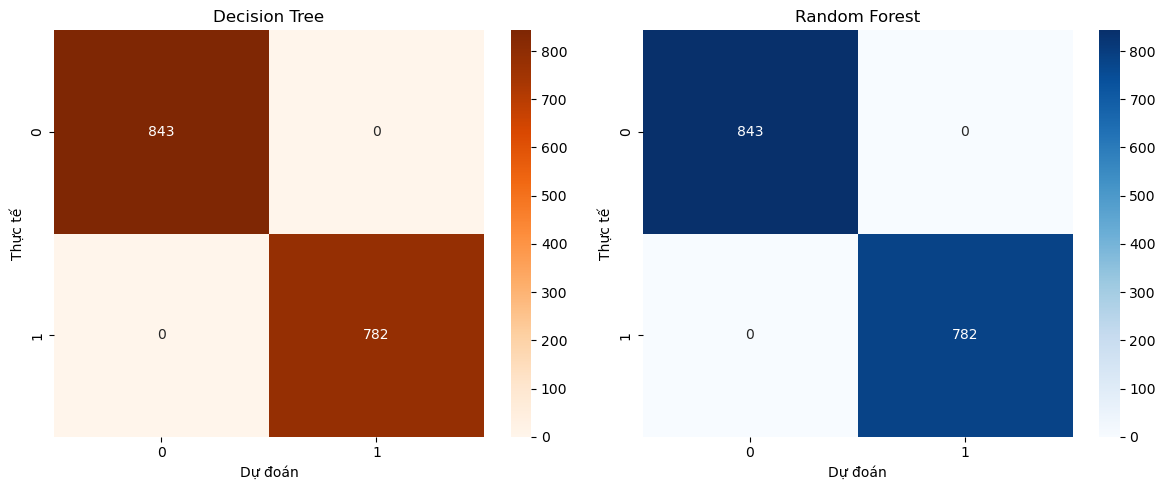

So sánh đường cong ROC


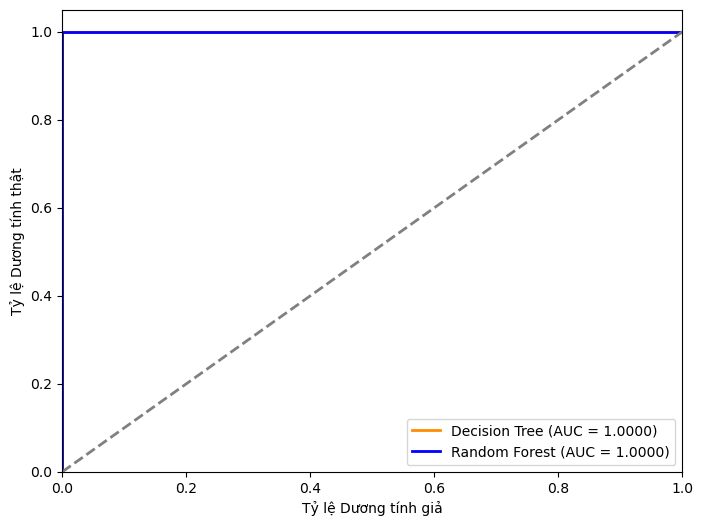

In [ ]:
print("So sánh ma trận nhầm lẫn")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Decision Tree
cm_tree = confusion_matrix(y_test, ket_qua_tree)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Oranges', ax=axes[0])
axes[0].set_title('Decision Tree')
axes[0].set_xlabel('Dự đoán'); axes[0].set_ylabel('Thực tế')

#Random Forest
cm_rf = confusion_matrix(y_test, ket_qua_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Dự đoán'); axes[1].set_ylabel('Thực tế')

plt.tight_layout()
plt.show()


print("So sánh đường cong ROC")
plt.figure(figsize=(8, 6))

prob_tree = final_tree.predict_proba(X_test)[:, 1]
prob_rf = final_rf.predict_proba(X_test)[:, 1]

fpr_tree, tpr_tree, _ = roc_curve(y_test, prob_tree)
plt.plot(fpr_tree, tpr_tree, color='darkorange', lw=2, label=f'Decision Tree (AUC = {auc(fpr_tree, tpr_tree):.4f})')

fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf)
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, 
         label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('Tỷ lệ Dương tính giả')
plt.ylabel('Tỷ lệ Dương tính thật') 
plt.legend(loc="lower right")
plt.show()